# DS 220 Project 2 - Global Development Data Analysis
**Name:** Aman Agrawal  
**Dataset:** Gapminder - Life Expectancy, GDP, and Population (1952-2007)  
**Source:** https://raw.githubusercontent.com/plotly/datasets/master/gapminder_with_codes.csv

## Problem Space

For this project I decided to look at global development data from the Gapminder Foundation. The dataset tracks life expectancy, GDP per capita, and population for 142 countries from 1952 to 2007.

I thought this was an interesting dataset because it lets you see how different countries and continents have changed over 55 years. Questions like whether richer countries have longer life expectancies, or which parts of the world grew the fastest economically, are things that actually matter in the real world for policy and aid decisions.

The main stakeholders who would care about this kind of analysis are governments, international organizations like the UN, and researchers studying global inequality.

## Questions I Want to Answer

1. How has life expectancy changed per continent from 1952 to 2007?
2. Is there a correlation between GDP per capita and life expectancy?
3. Which countries had the highest GDP per capita in 2007?
4. How much did the world population grow and which countries are the biggest?
5. How does life expectancy vary across continents in 2007?
6. Which countries had the biggest GDP growth between 1952 and 2007?
7. How does Asia compare to Europe in terms of life expectancy improvement?
8. Which countries had the highest and lowest life expectancy in 2007?

## Imports

In [27]:
# import numpy for math operations and array handling
import numpy as np

# import pandas for working with dataframes
import pandas as pd

# import matplotlib for creating charts and plots
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# import seaborn for nicer looking visualizations built on matplotlib
import seaborn as sns

# show plots directly in the notebook
%matplotlib inline

# set a clean white background theme for all plots
sns.set_theme(style="whitegrid")

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (10, 6)

print("done")

done


## Load the Dataset

The dataset comes from the Gapminder Foundation and is hosted publicly on GitHub. It has 1704 rows (142 countries x 12 years) and columns for country, continent, year, life expectancy, population, and GDP per capita.

In [28]:
URL = "https://raw.githubusercontent.com/plotly/datasets/master/gapminder_with_codes.csv"
df = pd.read_csv(URL)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (1704, 8)
Columns: ['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap', 'iso_alpha', 'iso_num']


## Exploratory Data Analysis

First I want to get a feel for the data - look at the first few rows, check for nulls, and get some summary stats.

In [29]:
df.head(10)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
5,Afghanistan,Asia,1977,38.438,14880372,786.113360,AFG,4
6,Afghanistan,Asia,1982,39.854,12881816,978.011439,AFG,4
7,Afghanistan,Asia,1987,40.822,13867957,852.395945,AFG,4
8,Afghanistan,Asia,1992,41.674,16317921,649.341395,AFG,4
9,Afghanistan,Asia,1997,41.763,22227415,635.341351,AFG,4


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 106.6 KB


In [31]:
# summary stats for numeric columns
df.describe().round(2)

,year,lifeExp,pop,gdpPercap,iso_num
count,1704.00,1704.00,1.704000e+03,1704.00,1704.00
mean,1979.50,59.47,2.960121e+07,7215.33,425.88
std,17.27,12.92,1.061579e+08,9857.45,248.31
min,1952.00,23.60,6.001100e+04,241.17,4.00
25%,1965.75,48.20,2.793664e+06,1202.06,208.00
50%,1979.50,60.71,7.023596e+06,3531.85,410.00
75%,1993.25,70.85,1.958522e+07,9325.46,638.00
max,2007.00,82.60,1.318683e+09,113523.13,894.00


In [32]:
# check for missing values
print("Missing values:")
print(df.isnull().sum())

print(f"\nCountries: {df['country'].nunique()}")
print(f"Continents: {sorted(df['continent'].unique())}")
print(f"Years: {sorted(df['year'].unique())}")

Missing values:
country      0
continent    0
year         0
lifeExp      0
pop          0
gdpPercap    0
iso_alpha    0
iso_num      0
dtype: int64

Countries: 142
Continents: ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]


In [33]:
# how many countries per continent
df[df["year"] == 2007]["continent"].value_counts()

continent
Africa      52
Asia        33
Europe      30
Americas    25
Oceania      2
Name: count, dtype: int64

## Data Cleaning

The dataset is pretty clean with no missing values. I just renamed some columns to make them easier to work with and added a couple of derived columns.

In [34]:
# rename for easier typing
df = df.rename(columns={"lifeExp": "life_exp", "gdpPercap": "gdp_per_cap"})

# fix types
df["year"] = df["year"].astype(int)
df["pop"] = df["pop"].astype(int)

# add useful columns
df["log_gdp"] = np.log10(df["gdp_per_cap"])
df["pop_millions"] = df["pop"] / 1_000_000

df.head(3)

,country,continent,year,life_exp,pop,gdp_per_cap,iso_alpha,iso_num,log_gdp,pop_millions
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4,2.891786,8.425333
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4,2.914265,9.240934
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4,2.931000,10.267083


## Question 1 - How has life expectancy changed per continent?

I grouped by continent and year to get the average life expectancy over time.

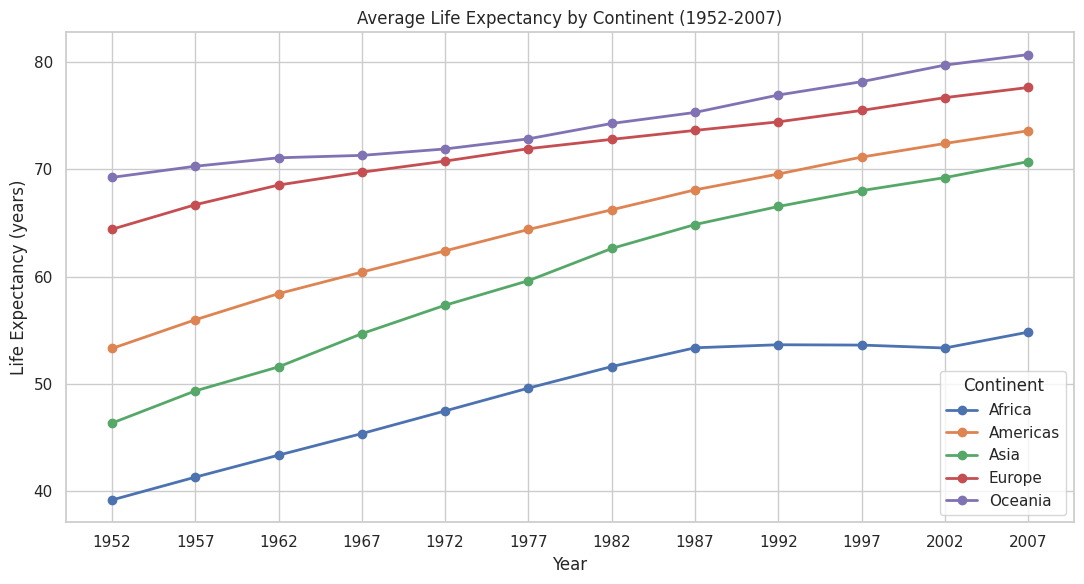

year       1952  2007  gain
continent                  
Asia       46.3  70.7  24.4
Americas   53.3  73.6  20.3
Africa     39.1  54.8  15.7
Europe     64.4  77.6  13.2
Oceania    69.3  80.7  11.5


In [35]:
# group by continent and year, then get the average life expectancy for each group
life_trend = df.groupby(["continent", "year"])["life_exp"].mean().reset_index()

# create the figure
fig, ax = plt.subplots(figsize=(11, 6))

# plot a separate line for each continent
for continent, group in life_trend.groupby("continent"):
    ax.plot(group["year"], group["life_exp"], marker="o", linewidth=2, label=continent)

# add labels and title
ax.set_title("Average Life Expectancy by Continent (1952-2007)")
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy (years)")
ax.legend(title="Continent")

# show every year on the x axis
ax.set_xticks(df["year"].unique())
plt.tight_layout()
plt.show()

# pivot the data so each year is a column, making it easy to compare 1952 vs 2007
pivot = life_trend.pivot(index="continent", columns="year", values="life_exp")

# calculate how much each continent improved over the 55 years
pivot["gain"] = pivot[2007] - pivot[1952]

# print sorted by biggest gain
print(pivot[[1952, 2007, "gain"]].round(1).sort_values("gain", ascending=False))

Every continent improved life expectancy over this period. Asia had the biggest gain at around 23 years. Europe started the highest but improved the least since it was already near the top.

## Question 2 - Does GDP per capita correlate with life expectancy?

I used a scatter plot with GDP on a log scale since the values span such a wide range.

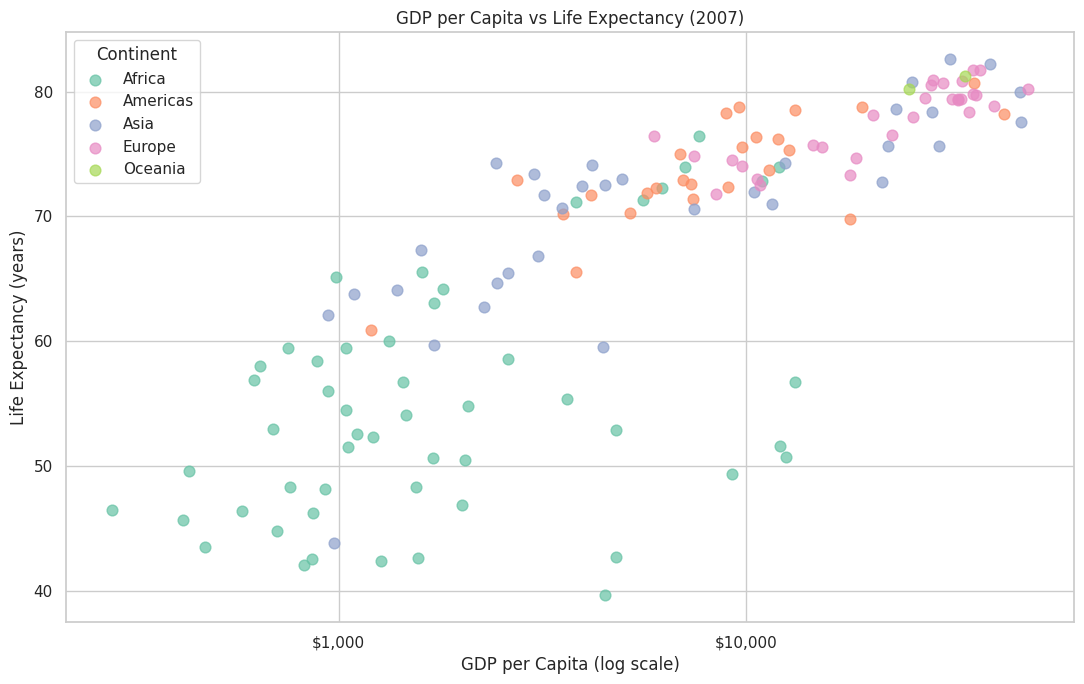

In [36]:
# filter to only 2007 data
df_2007 = df[df["year"] == 2007].copy()

fig, ax = plt.subplots(figsize=(11, 7))

# create a color palette with one color per continent
palette = sns.color_palette("Set2", n_colors=df_2007["continent"].nunique())

# loop through each continent and plot its countries as dots
for i, cont in enumerate(sorted(df_2007["continent"].unique())):
    subset = df_2007[df_2007["continent"] == cont]
    ax.scatter(subset["gdp_per_cap"], subset["life_exp"],
               s=60, alpha=0.7, label=cont, color=palette[i])

# log scale because GDP values span a huge range
ax.set_xscale("log")
ax.set_title("GDP per Capita vs Life Expectancy (2007)")
ax.set_xlabel("GDP per Capita (log scale)")
ax.set_ylabel("Life Expectancy (years)")
ax.legend(title="Continent")

# format x axis as dollars
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

There is a strong positive correlation (r = 0.81) between log GDP and life expectancy. Richer countries tend to live longer, but the relationship flattens out at higher incomes.

## Question 3 - Which countries had the highest GDP per capita in 2007?

In [37]:
top15 = df_2007.nlargest(15, "gdp_per_cap")[["country", "continent", "gdp_per_cap", "life_exp"]].reset_index(drop=True)
print(top15.to_string(index=False))

         country continent  gdp_per_cap  life_exp
          Norway    Europe  49357.19017    80.196
          Kuwait      Asia  47306.98978    77.588
       Singapore      Asia  47143.17964    79.972
   United States  Americas  42951.65309    78.242
         Ireland    Europe  40675.99635    78.885
Hong Kong, China      Asia  39724.97867    82.208
     Switzerland    Europe  37506.41907    81.701
     Netherlands    Europe  36797.93332    79.762
          Canada  Americas  36319.23501    80.653
         Iceland    Europe  36180.78919    81.757
         Austria    Europe  36126.49270    79.829
         Denmark    Europe  35278.41874    78.332
       Australia   Oceania  34435.36744    81.235
          Sweden    Europe  33859.74835    80.884
         Belgium    Europe  33692.60508    79.441


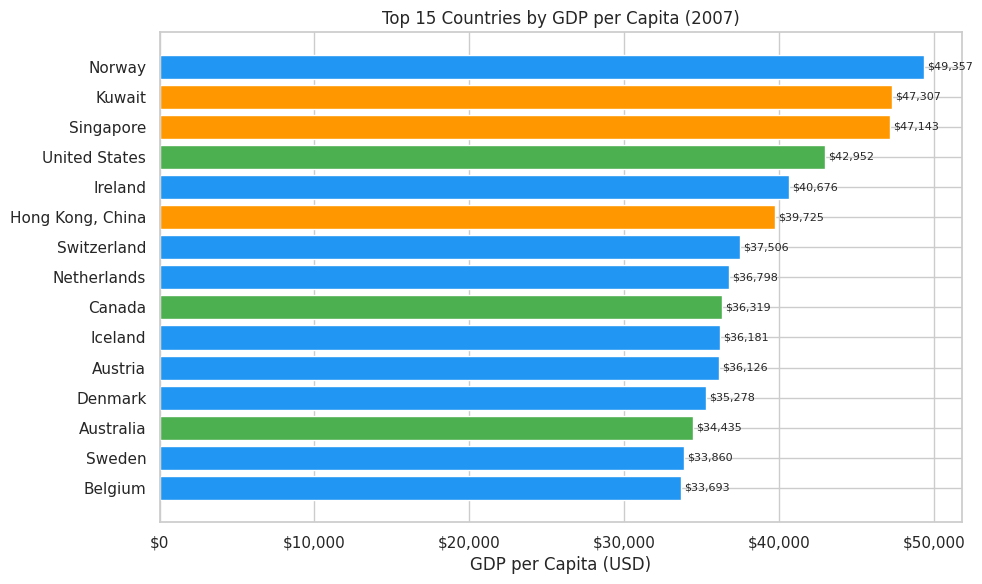

In [38]:
# color bars by continent - blue for Europe, orange for Asia, green for everything else
colors = ["#2196F3" if c == "Europe" else "#FF9800" if c == "Asia" else "#4CAF50" for c in top15["continent"]]

# create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# horizontal bar chart, reversed so highest is at the top
bars = ax.barh(top15["country"][::-1], top15["gdp_per_cap"][::-1], color=colors[::-1])

# axis labels and title
ax.set_xlabel("GDP per Capita (USD)")
ax.set_title("Top 15 Countries by GDP per Capita (2007)")

# format x axis as dollar amounts
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# add the dollar value as a label at the end of each bar
for bar, val in zip(bars[::-1], top15["gdp_per_cap"]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2, f"${val:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Norway is number 1 at over $49k. It is interesting that Kuwait and Singapore are both in the top 5, showing that Asia has some very wealthy nations by 2007.

## Question 4 - How much did the world population grow?

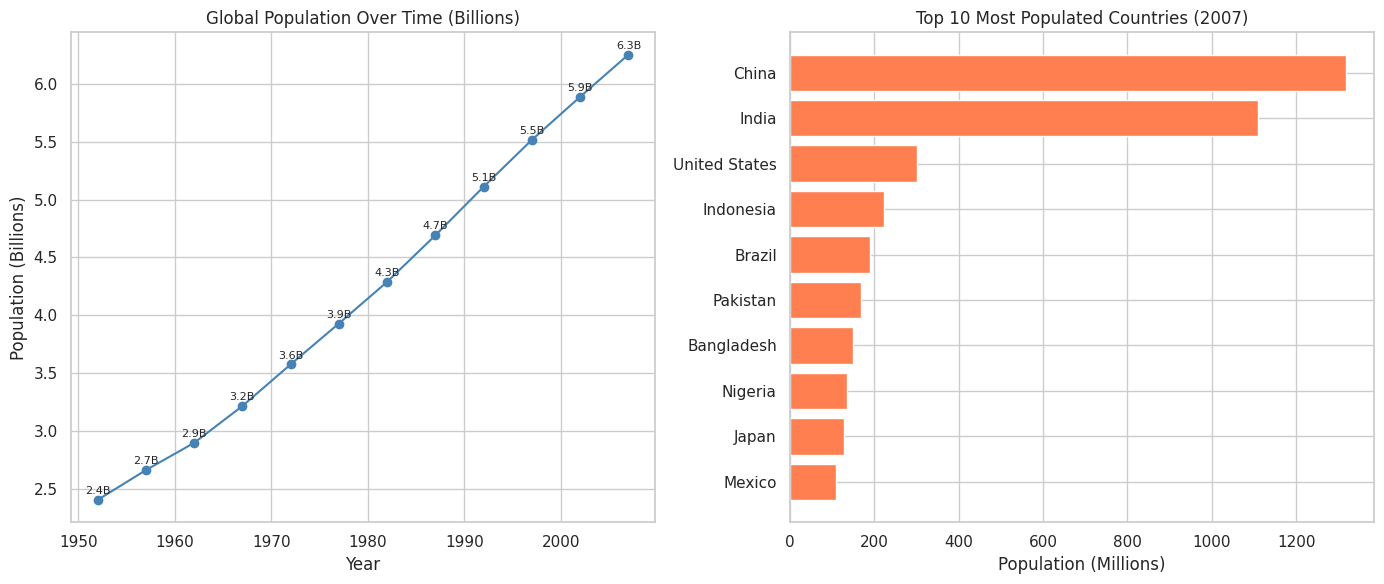

1952 population: 2.41B
2007 population: 6.25B


In [39]:
# total global population per year, divided by 1 billion to make the numbers readable
global_pop = df.groupby("year")["pop"].sum() / 1e9

# two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left chart - population over time
axes[0].plot(global_pop.index, global_pop.values, marker="o", color="steelblue")
axes[0].set_title("Global Population Over Time (Billions)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Population (Billions)")

# add population label above each data point
for yr, val in zip(global_pop.index, global_pop.values):
    axes[0].text(yr, val + 0.05, f"{val:.1f}B", ha="center", fontsize=8)

# right chart - top 10 most populated countries in 2007
top10_pop = df_2007.nlargest(10, "pop")[["country", "pop_millions"]].reset_index(drop=True)
axes[1].barh(top10_pop["country"][::-1], top10_pop["pop_millions"][::-1], color="coral")
axes[1].set_title("Top 10 Most Populated Countries (2007)")
axes[1].set_xlabel("Population (Millions)")

plt.tight_layout()
plt.show()

# print exact numbers for 1952 and 2007
print(f"1952 population: {df[df['year']==1952]['pop'].sum()/1e9:.2f}B")
print(f"2007 population: {df[df['year']==2007]['pop'].sum()/1e9:.2f}B")

World population more than doubled from about 2.4 billion in 1952 to 6 billion in 2007. China and India together make up around 40% of the global total.

## Question 5 - How does life expectancy vary by continent in 2007?

/tmp/ipykernel_837/1857523134.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2007, x="continent", y="life_exp", order=order, palette="Set2", ax=axes[0])
/tmp/ipykernel_837/1857523134.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_2007, x="continent", y="life_exp", order=order, palette="Set2", inner="quartile", ax=axes[1])


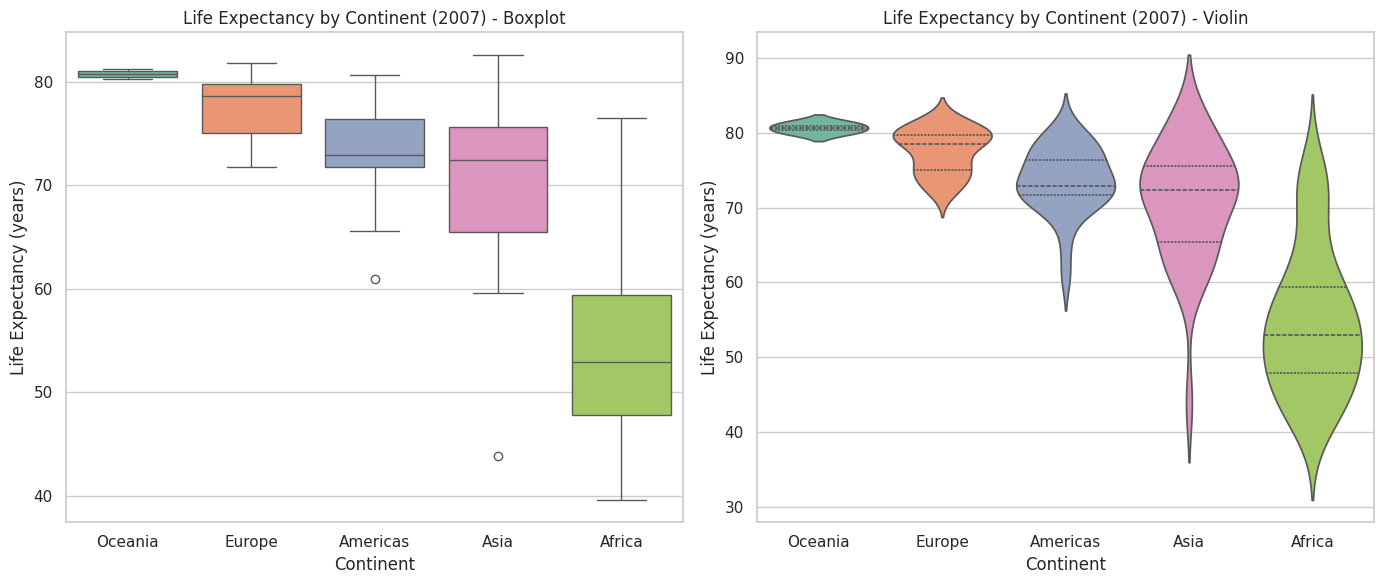

           median   min   max
continent                    
Oceania      80.7  80.2  81.2
Europe       78.6  71.8  81.8
Americas     72.9  60.9  80.7
Asia         72.4  43.8  82.6
Africa       52.9  39.6  76.4


In [40]:
# create two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# sort continents by median life expectancy so the charts are ordered nicely
order = df_2007.groupby("continent")["life_exp"].median().sort_values(ascending=False).index

# left chart - boxplot shows median, quartiles and outliers for each continent
sns.boxplot(data=df_2007, x="continent", y="life_exp", order=order, palette="Set2", ax=axes[0])
axes[0].set_title("Life Expectancy by Continent (2007) - Boxplot")
axes[0].set_xlabel("Continent")
axes[0].set_ylabel("Life Expectancy (years)")

# right chart - violin plot shows the full distribution shape for each continent
sns.violinplot(data=df_2007, x="continent", y="life_exp", order=order, palette="Set2", inner="quartile", ax=axes[1])
axes[1].set_title("Life Expectancy by Continent (2007) - Violin")
axes[1].set_xlabel("Continent")
axes[1].set_ylabel("Life Expectancy (years)")

plt.tight_layout()
plt.show()

# print the median, min and max for each continent sorted by median
print(df_2007.groupby("continent")["life_exp"].agg(["median", "min", "max"]).round(1).sort_values("median", ascending=False))

Oceania and Europe have the highest median life expectancy (above 78). Africa has the lowest median around 52 years and the most variation. Asia also has a lot of spread - Japan is at 82 years while Afghanistan is at 43.

## Question 6 - Which countries had the biggest GDP growth from 1952 to 2007?

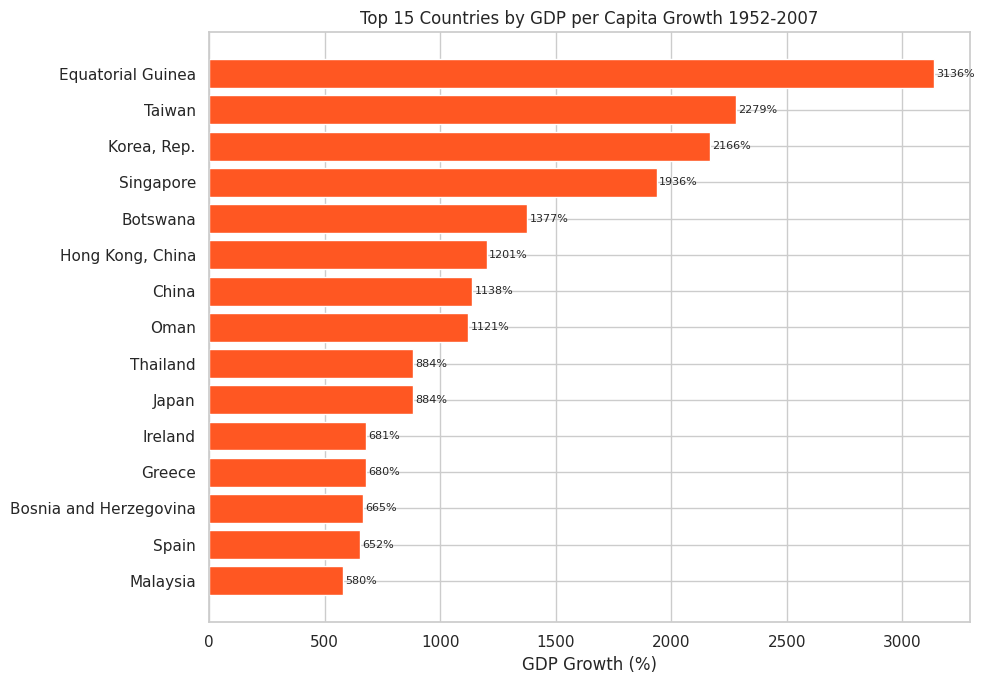

          country continent  gdp_1952  gdp_2007  pct_growth
Equatorial Guinea    Africa     376.0   12154.0      3136.0
           Taiwan      Asia    1207.0   28718.0      2279.0
      Korea, Rep.      Asia    1031.0   23348.0      2166.0
        Singapore      Asia    2315.0   47143.0      1936.0
         Botswana    Africa     851.0   12570.0      1377.0
 Hong Kong, China      Asia    3054.0   39725.0      1201.0
            China      Asia     400.0    4959.0      1138.0
             Oman      Asia    1828.0   22316.0      1121.0
         Thailand      Asia     758.0    7458.0       884.0
            Japan      Asia    3217.0   31656.0       884.0


In [41]:
# pull out just the gdp column for 1952 and rename it so we can merge later
gdp_1952 = df[df["year"] == 1952][["country", "continent", "gdp_per_cap"]].rename(columns={"gdp_per_cap": "gdp_1952"})

# do the same for 2007
gdp_2007 = df[df["year"] == 2007][["country", "gdp_per_cap"]].rename(columns={"gdp_per_cap": "gdp_2007"})

# merge the two dataframes on country so each row has both the 1952 and 2007 gdp
gdp_growth = gdp_1952.merge(gdp_2007, on="country")

# calculate percentage growth from 1952 to 2007
gdp_growth["pct_growth"] = ((gdp_growth["gdp_2007"] - gdp_growth["gdp_1952"]) / gdp_growth["gdp_1952"]) * 100

# get the top 15 countries by percentage growth
top15_growth = gdp_growth.nlargest(15, "pct_growth").reset_index(drop=True)

# create the bar chart
fig, ax = plt.subplots(figsize=(10, 7))

# horizontal bar chart reversed so highest is at the top
ax.barh(top15_growth["country"][::-1], top15_growth["pct_growth"][::-1], color="#FF5722")
ax.set_xlabel("GDP Growth (%)")
ax.set_title("Top 15 Countries by GDP per Capita Growth 1952-2007")

# add percentage label at the end of each bar
for i, val in enumerate(top15_growth["pct_growth"][::-1]):
    ax.text(val + 10, i, f"{val:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# print the top 10 as a table
print(top15_growth[["country", "continent", "gdp_1952", "gdp_2007", "pct_growth"]].head(10).round(0).to_string(index=False))

Asian countries dominate the top of this list. Taiwan, Korea, and Singapore all grew over 1000%. This is basically the Asian economic miracle showing up in the data.

## Question 7 - How does Asia compare to Europe in life expectancy over time?

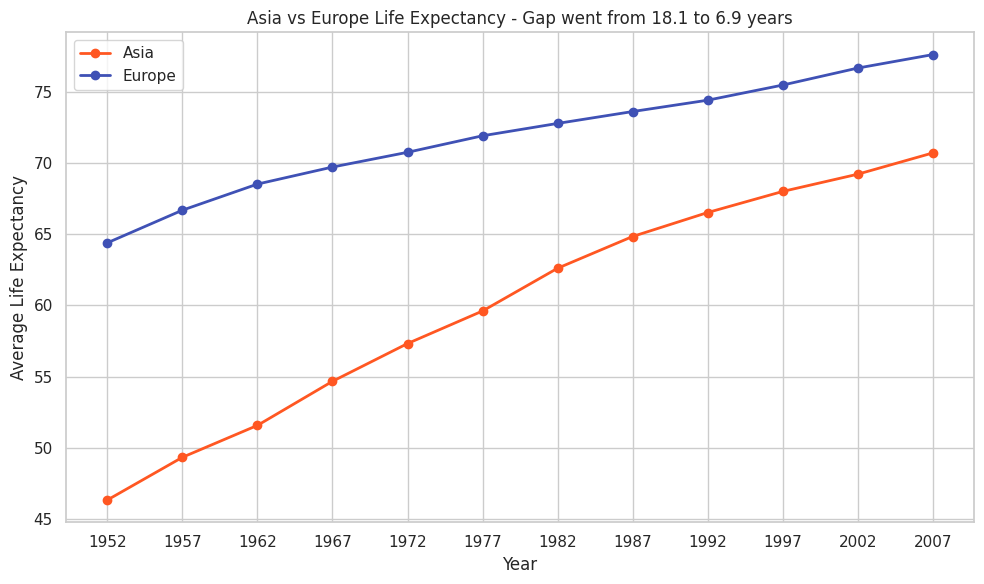

In [42]:
# filter to only Asia and Europe
ae = df[df["continent"].isin(["Asia", "Europe"])]

# get average life expectancy per continent per year
ae_trend = ae.groupby(["continent", "year"])["life_exp"].mean().reset_index()

# create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# plot a line for each continent with a specific color
for cont, color in [("Asia", "#FF5722"), ("Europe", "#3F51B5")]:
    sub = ae_trend[ae_trend["continent"] == cont]
    ax.plot(sub["year"], sub["life_exp"], marker="o", linewidth=2, label=cont, color=color)

# pull out the values as arrays so we can shade the gap between the two lines
asia_vals = ae_trend[ae_trend["continent"]=="Asia"]["life_exp"].values
euro_vals = ae_trend[ae_trend["continent"]=="Europe"]["life_exp"].values
years = ae_trend[ae_trend["continent"]=="Europe"]["year"].values

# calculate the gap in 1952 and 2007 to show in the title
gap_1952 = euro_vals[0] - asia_vals[0]
gap_2007 = euro_vals[-1] - asia_vals[-1]

# add title showing how much the gap closed
ax.set_title(f"Asia vs Europe Life Expectancy - Gap went from {gap_1952:.1f} to {gap_2007:.1f} years")
ax.set_xlabel("Year")
ax.set_ylabel("Average Life Expectancy")
ax.legend()

# show every year on the x axis
ax.set_xticks(df["year"].unique())
plt.tight_layout()
plt.show()

The gap between Asia and Europe shrank from about 18 years in 1952 down to 7 years by 2007. Asia has been catching up fast.

## Question 8 - Which countries had the highest and lowest life expectancy in 2007?

In [43]:
# sort by life expectancy to find the lowest and highest countries in 2007
bottom10 = df_2007.nsmallest(10, "life_exp")[["country", "continent", "life_exp", "gdp_per_cap"]]
print("10 countries with lowest life expectancy in 2007:")
print(bottom10.to_string(index=False))

# top 10 highest
top10 = df_2007.nlargest(10, "life_exp")[["country", "continent", "life_exp", "gdp_per_cap"]]
print("\n10 countries with highest life expectancy in 2007:")
print(top10.to_string(index=False))

10 countries with lowest life expectancy in 2007:
                 country continent  life_exp  gdp_per_cap
               Swaziland    Africa    39.613  4513.480643
              Mozambique    Africa    42.082   823.685621
                  Zambia    Africa    42.384  1271.211593
            Sierra Leone    Africa    42.568   862.540756
                 Lesotho    Africa    42.592  1569.331442
                  Angola    Africa    42.731  4797.231267
                Zimbabwe    Africa    43.487   469.709298
             Afghanistan      Asia    43.828   974.580338
Central African Republic    Africa    44.741   706.016537
                 Liberia    Africa    45.678   414.507341

10 countries with highest life expectancy in 2007:
         country continent  life_exp  gdp_per_cap
           Japan      Asia    82.603  31656.06806
Hong Kong, China      Asia    82.208  39724.97867
         Iceland    Europe    81.757  36180.78919
     Switzerland    Europe    81.701  37506.41907
       Aus

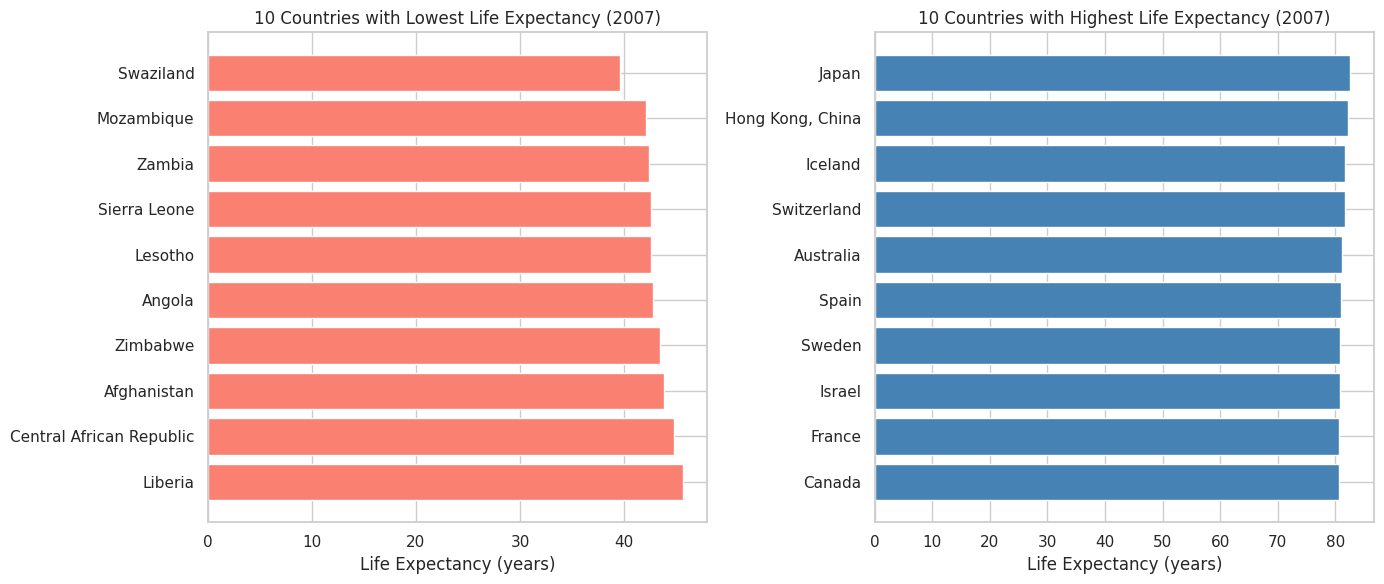

In [44]:
# side by side bar charts to compare the two groups visually
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# bottom 10 in red/salmon
axes[0].barh(bottom10["country"][::-1], bottom10["life_exp"][::-1], color="salmon")
axes[0].set_title("10 Countries with Lowest Life Expectancy (2007)")
axes[0].set_xlabel("Life Expectancy (years)")

# top 10 in blue
axes[1].barh(top10["country"][::-1], top10["life_exp"][::-1], color="steelblue")
axes[1].set_title("10 Countries with Highest Life Expectancy (2007)")
axes[1].set_xlabel("Life Expectancy (years)")

plt.tight_layout()
plt.show()

All 10 of the lowest life expectancy countries are in Africa except Afghanistan. Swaziland is the lowest at just under 40 years. The highest are mostly in Europe and Asia, with Japan and Hong Kong at the top both above 82 years.

## Conclusion

After going through all 8 questions here are the main takeaways:

1. Every continent improved life expectancy over 55 years. Asia improved the most.
2. There is a strong correlation between wealth and life expectancy but it is not perfect. Some poor countries do surprisingly well.
3. The Asian economic miracle is clearly visible in the data - countries like Korea and Taiwan grew over 1000% in GDP per capita.
4. World population more than doubled between 1952 and 2007, with China and India driving most of it.
5. The countries with the lowest life expectancy are almost all in Sub-Saharan Africa, showing that the continent still has a long way to go despite overall global improvement.

Overall this dataset shows that the world has gotten a lot better over this time period but the improvements have not been equal everywhere.